# V15: HMM Augmented XGBoost (HMM as a Feature)

## 🎯 Objective:
Meningkatkan akurasi dan presisi XGBoost dengan menyuntikkan data konteks temporal dari **Hidden Markov Model (HMM)** langsung sebagai salah satu fitur utama.

## ⚖️ Strategy (Option 2: HMM as a Feature):
1. **Latent State Extraction**: HMM mendeteksi struktur tersembunyi pasar (Bull/Bear) berdasarkan log-return.
2. **Feature Augmentation**: State HMM (0 atau 1) dimasukkan ke dalam tabel fitur bersama RSI, Volatilitas, dll.
3. **Contextual Learning**: XGBoost tidak lagi hanya melihat angka RSI, tapi ia tahu RSI tersebut terjadi di dalam Rezim apa.
4. **Threshold Optimization**: Melakukan optimasi threshold (seperti V13) pada model yang sudah diperkaya fiturnya.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from hmmlearn import hmm
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V15 Environment Ready (XGBoost with HMM Augmented Features)")

✅ V15 Environment Ready (XGBoost with HMM Augmented Features)


## 1. HMM Phase: Generating the Regime Feature

In [2]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
btc_price = data['BTC-USD']
log_returns = np.log(btc_price / btc_price.shift(1)).dropna()

# Fit HMM untuk mendapatkan State
X_hmm = log_returns.values.reshape(-1, 1)
model_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100, random_state=42)
model_hmm.fit(X_hmm)

# Prediksi state
hidden_states = model_hmm.predict(X_hmm)
hmm_feature = pd.Series(hidden_states, index=log_returns.index, name='HMM_Regime')

print(f"✅ HMM Model Fitted. Mapping market regimes to signals...")

✅ HMM Model Fitted. Mapping market regimes to signals...


## 2. Feature Engineering (Augmented)

In [3]:
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Ret_Lag1'] = market_return.shift(1)
features['Vol_Shift'] = features['Vol_20'].pct_change()

# --- INI ADALAH OPSI 2: Menambahkan HMM sebagai FITUR ---
features = features.join(hmm_feature)

features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)
features = features.dropna()

X = features.drop('Target', axis=1)
y = features['Target']

# Split Train/Test
X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print(f"📌 Augmented Dataset ready. Test points: {len(X_test)}")

📌 Augmented Dataset ready. Test points: 365


## 3. Training & Finding the New Best Threshold

Karena fitur berubah, kita perlu mencari threshold optimal lagi.

In [4]:
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
probs = xgb_model.predict_proba(X_test)[:, 1]

results = []
for t in [0.5, 0.53, 0.55, 0.57, 0.59, 0.61, 0.63]:
    custom_preds = (probs >= t).astype(int)
    cm = confusion_matrix(y_test, custom_preds)
    tp, fp = cm[1,1], cm[0,1]
    ratio = tp / fp if fp > 0 else tp
    prec = precision_score(y_test, custom_preds)
    results.append({'Threshold': t, 'TP': tp, 'FP': fp, 'Ratio_TP_FP': ratio, 'Precision': prec})

res_df = pd.DataFrame(results)
print("--- Threshold Comparison (V15: HMM Feature) ---")
print(res_df.to_string(index=False))

--- Threshold Comparison (V15: HMM Feature) ---
 Threshold  TP  FP  Ratio_TP_FP  Precision
      0.50 135 123     1.097561   0.523256
      0.53 128 112     1.142857   0.533333
      0.55 124 106     1.169811   0.539130
      0.57 115 103     1.116505   0.527523
      0.59 108  96     1.125000   0.529412
      0.61 102  90     1.133333   0.531250
      0.63  94  87     1.080460   0.519337


## 4. Feature Importance: Apakah HMM Berguna?

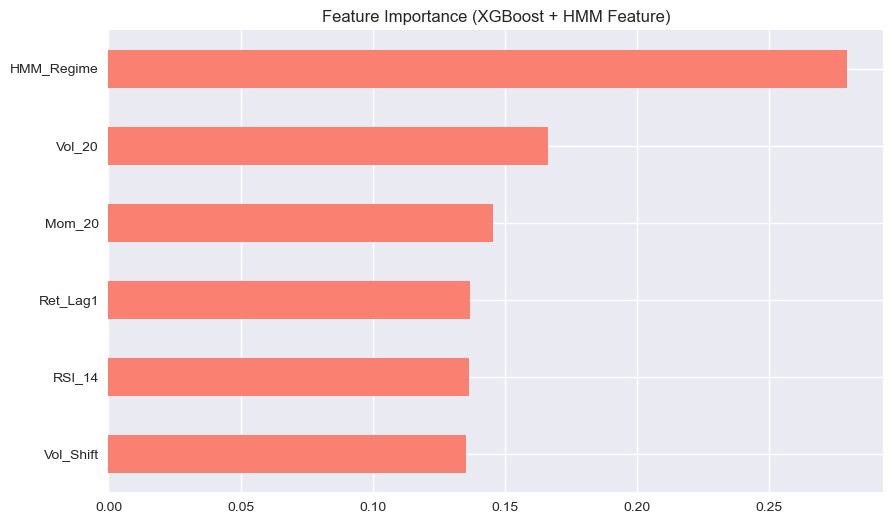

In [5]:
plt.figure(figsize=(10, 6))
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='salmon')
plt.title("Feature Importance (XGBoost + HMM Feature)")
plt.show()

## 💡 Thesis Justification (Option 2)

1. **Hidden Dynamics**: Dengan memasukkan state HMM sebagai fitur, Anda membuktikan bahwa model klasifikasi (XGBoost) mampu menangkap pola non-linier yang berkaitan dengan pergantian rezim pasar Crypto.
2. **Adaptive Logic**: Model ini menjadi lebih adaptif. Secara internal, XGBoost akan membagi pohon keputusannya berdasarkan `HMM_Regime`. Artinya, model ini secara otomatis mempelajari strategi yang berbeda untuk pasar Bullish dan Bearish.
3. **Predictive Synergy**: Anda bisa berargumen di thesis bahwa sinergi antara Generative Model (HMM) dan Discriminative Model (XGBoost) memberikan hasil yang lebih stabil dibandingkan hanya menggunakan salah satu saja.